In [ ]:
# pip install pandas numpy matplotlib openpyxl

# Exploratory Data Analysis and KC Cleaning for Algebra Data

This notebook cleans the raw algebra interaction data down to five KCs relevant to first-degree linear equations, ready for BKT parameter fitting.

The raw data is messy: 1828 distinct KC labels, multi-KC rows, noisy step names, and around 40% exact duplicates. By the end we have a clean, deduplicated, single-KC-per-row dataframe with five target skills.

# 1. Imports and paths

In [ ]:
from pathlib import Path
import gc
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt


# PROJECT DIRECTORIES 
BASE_DIR = Path("..").resolve()          # app/
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = DATA_DIR / "outputs"


## 2. Define the input schema and load the raw files

Only the columns needed for this analysis are loaded to reduce memory. Dtypes used for memory efficiency. 

Important! The 2006–2007 and 2008–2009 files use slightly different KC column names, so the loader standardizes them into a single column: **KC(Default)**.


In [ ]:
# ── Dataset selection ────────────────────────────────────────────────────────
# Change to "2006-07" and re-run the full notebook to generate the other year's CSV.
DATASET_YEAR = "2008-09"

# Columns needed for each dataset (2008-09 uses a different KC column name)
cols_06 = [
    "Row", "Anon Student Id", "Problem Name", "Step Name",
    "KC(Default)", "Correct First Attempt", "Incorrects", "Hints", "Corrects",
    "Step Start Time", "Step End Time",
]

cols_08 = [
    "Row", "Anon Student Id", "Problem Name", "Step Name",
    "KC(SubSkills)", "Correct First Attempt", "Incorrects", "Hints", "Corrects",
    "Step Start Time", "Step End Time",
]

# Memory-efficient dtypes
dtype_06 = {
    "Row": "Int32", "Anon Student Id": "category", "Problem Name": "category",
    "Step Name": "category", "KC(Default)": "category",
    "Correct First Attempt": "Int8", "Incorrects": "Int16", "Hints": "Int16", "Corrects": "Int16",
}

dtype_08 = {
    "Row": "Int32", "Anon Student Id": "category", "Problem Name": "category",
    "Step Name": "category", "KC(SubSkills)": "category",
    "Correct First Attempt": "Int8", "Incorrects": "Int16", "Hints": "Int16", "Corrects": "Int16",
}

# FILE PATHS
TRAIN_06_PATH = RAW_DIR / "algebra_2006_2007_train.txt"
TRAIN_08_PATH = RAW_DIR / "algebra_2008_2009_train.txt"

# Load only the selected dataset — avoids loading both large files into memory.
if DATASET_YEAR == "2006-07":
    _df_train = pd.read_csv(TRAIN_06_PATH, sep="\t", usecols=cols_06, dtype=dtype_06)
else:
    _df_train = pd.read_csv(TRAIN_08_PATH, sep="\t", usecols=cols_08, dtype=dtype_08)
    _df_train.rename(columns={"KC(SubSkills)": "KC(Default)"}, inplace=True)

gc.collect()

print(f"Dataset year : {DATASET_YEAR}")
print(f"Train shape  : {_df_train.shape}")
print(_df_train.head(5))
print(_df_train.columns.tolist())

## Overview of the merged dataset

In [ ]:
def dataset_overview(df, kc_col="KC(Default)"):
    """Print a compact summary of the dataset."""
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Students:", df["Anon Student Id"].nunique())
    print("Problems:", df["Problem Name"].nunique())
    print("Steps:", df["Step Name"].nunique())
    if kc_col in df.columns:
        print("Unique KCs:", df[kc_col].nunique())

dataset_overview(_df_train)


Shape: (8918054, 11)
Columns: ['Row', 'Anon Student Id', 'Problem Name', 'Step Name', 'Step Start Time', 'Step End Time', 'Correct First Attempt', 'Incorrects', 'Hints', 'Corrects', 'KC(Default)']
Students: 3310
Problems: 188368
Steps: 700635
Unique KCs: 1828


## 4. Helpers for equation-pattern detection
The original KC labels are noisy and broad as both datasets deal with more algebra concepts that are not strictly first-degree linear equations. For this reason, **rule-based helpers** are used to identify whether a step truly belongs to the reduced target domain.

The goal is to keep the final KC taxonomy narrow and focused on **first-degree linear equations**.


The helpers related to parentheses and combine-like-terms operations were introduced after the first BKT model fit, as the initial results produced implausible parameter estimates, including excessively high guess and prior probabilities. This suggested that the KC mapping was still too broad and was capturing steps outside the intended domain. Therefore, the filtering rules were refined to retain only steps involving direct operations on the variable.

In [ ]:
# Helpers for detecting whether a step really involves parentheses
# KC: expand / eliminate parentheses

def has_variable_inside_parentheses(step_name):
    """Return True if at least one parenthesized group contains a variable."""
    if pd.isna(step_name):
        return False
    
    s = str(step_name).replace(" ", "")
    groups = re.findall(r'\(([^()]*)\)', s)
    return any(re.search(r'[a-zA-Z]', g) for g in groups)

def is_denominator_parentheses(step_name):
    """Return True when parentheses appear as part of a denominator pattern."""
    if pd.isna(step_name):
        return False
    
    s = str(step_name).replace(" ", "")
    return bool(
        re.search(r'\([^=]+\)/', s) or
        re.search(r'/\([^=]+\)', s)
    )

def is_true_expand_eliminate_parentheses(step_name):
    """Identify genuine distributive/eliminate-parentheses steps.

    Conditions:
    - must look like an equation,
    - must contain parentheses,
    - must not involve denominator-parentheses cases,
    - must contain a variable inside parentheses,
    - must show multiplication or a sign applied to the parenthesized expression.
    """
    if pd.isna(step_name):
        return False

    s = str(step_name).replace(" ", "")

    if "=" not in s:
        return False
    if "(" not in s or ")" not in s:
        return False

    # avoid denominator cases
    if is_denominator_parentheses(s):
        return False

    # at least, one variable inside the parenthesis
    if not has_variable_inside_parentheses(s):
        return False

    patterns = [
        r'(\d+(\.\d+)?|[a-zA-Z])\([^=]+\)',   # 2(x+3), d(x+3), 0.5(x-1)
        r'\([^=]+\)(\d+(\.\d+)?|[a-zA-Z])',   # (x+3)2, (x+3)y
        r'-\([^=]+\)'                         # -(x+3)
    ]

    return any(re.search(p, s) for p in patterns)

# ---------------------------------------------------------------------
# Helpers for strict "Combine Like Terms" detection
# ---------------------------------------------------------------------
def get_equation_sides(step_name):
    """Split an equation into left and right sides. Return (None, None) if invalid."""
    if pd.isna(step_name):
        return None, None

    s = str(step_name).replace(" ", "")
    if "=" not in s:
        return None, None

    parts = s.split("=")
    if len(parts) != 2:
        return None, None

    return parts[0], parts[1]


def split_terms(expr):
    """
    Split an algebraic expression into signed terms.
    Example:
        '2x+3x-4' -> ['2x', '3x', '-4']
    """
    if expr is None:
        return []

    s = expr.replace(" ", "")
    s = s.replace("-", "+-")
    if s.startswith("+-"):
        s = s[1:]

    return [t for t in s.split("+") if t != ""]


def is_simple_variable_term(term):
    """
    Accept only simple variable terms such as:
        x, -x, 2x, -3x, 0.5x, 2*x
    Reject:
        x/3, x^2, sqrt(x), (x+1), xy
    """
    if term is None:
        return False

    t = term.replace(" ", "")

    # Reject clearly non-linear / complex forms
    banned = ["(", ")", "/", "^", "sqrt", "sin", "cos", "tan", "log", "ln"]
    if any(b in t.lower() for b in banned):
        return False

    patterns = [
        r"^-?[a-zA-Z]$",                         # x, -x
        r"^-?\d+(\.\d+)?[a-zA-Z]$",             # 2x, -3.5y
        r"^-?\d+(\.\d+)?\*[a-zA-Z]$",           # 2*x, -3.5*y
    ]

    return any(re.fullmatch(p, t) for p in patterns)


def get_term_variable(term):
    vars_found = re.findall(r"[a-zA-Z]", term)
    if len(vars_found) == 1:
        return vars_found[0]
    return None


def side_has_like_variable_terms(expr):
    """
    True if one side contains at least two simple terms with the same variable:
        2x+3x
        x+x
        -4y+7y
    """
    terms = split_terms(expr)

    var_terms = []
    for term in terms:
        if is_simple_variable_term(term):
            v = get_term_variable(term)
            if v is not None:
                var_terms.append(v)

    counts = Counter(var_terms)
    return any(count >= 2 for count in counts.values())


def has_only_one_distinct_variable(step_name):
    """
    Keep the KC narrow: only one variable symbol in the whole equation.
    """
    if pd.isna(step_name):
        return False

    s = str(step_name)
    vars_found = set(re.findall(r"[a-zA-Z]", s))
    return len(vars_found) == 1


def is_true_combine_like_terms(step_name):
    """
    Strict version of Combine Like Terms:
    - must be an equation
    - no parentheses / denominators / powers / functions
    - only one variable symbol overall
    - at least one side has repeated like variable terms
    """
    if pd.isna(step_name):
        return False

    s = str(step_name).replace(" ", "")

    if "=" not in s:
        return False

    banned_patterns = ["(", ")", "/", "^", "sqrt", "sin", "cos", "tan", "log", "ln"]
    if any(p in s.lower() for p in banned_patterns):
        return False

    if not has_only_one_distinct_variable(s):
        return False

    left, right = get_equation_sides(s)
    if left is None or right is None:
        return False

    return side_has_like_variable_terms(left) or side_has_like_variable_terms(right)

## 6. KC mapping and preprocessing

The raw KC labels map into these five target skills. The mapping uses both string matching on the CTAT rule names and rule-based validation on the step text — the step-level validators were added after the first BKT fit returned implausible parameters, which pointed to the label matching being too loose.

In [ ]:
def map_kc(kc, step_name=None):

    """Map a raw KC label into the reduced KC taxonomy.

    The mapping combines:
    - raw label pattern matching,
    - rule-based validation using the step text,
    - explicit exclusion of off-domain or ambiguous cases.
    """
        
    if pd.isna(kc):
        return None

    kc_lower = str(kc).lower().strip()

    # Patterns that should be excluded from the reduced taxonomy
    exclude_patterns = [
        "skillrule: variable in denominator;",
        "clt-r-den",
        "clt-r-num",
        "combine-like-terms-r-sp",
    ]
    if any(p in kc_lower for p in exclude_patterns):
        return "Other"

    # 1. Expand / Eliminate Parentheses
    if (
        "skillrule: eliminate parens;" in kc_lower
        or "skillrule: calculate eliminate parens;" in kc_lower
        or "skillrule: do eliminate parens - whole;" in kc_lower
        or "skillrule: extract to consolidate vars;" in kc_lower
        or "skillrule: select eliminate parens" in kc_lower
    ):
        if is_true_expand_eliminate_parentheses(step_name):
            return "Expand / Eliminate Parentheses"
        return "Other"

    # 2. Combine Like Terms (STRICT: only variable consolidation)
    if (
        "skillrule: do combine terms - whole;" in kc_lower
        or "skillrule: consolidate vars, no coeff;" in kc_lower
        or "skillrule: consolidate vars with coeff;" in kc_lower
        or "skillrule: consolidate vars, any;" in kc_lower
    ):
        if is_true_combine_like_terms(step_name):
            return "Combine Like Terms"
        return "Other"

    # Optional CLT fallback, but only if the step really looks like CLT
    if (
        "clt" in kc_lower
        and "parens" not in kc_lower
        and "consolidate vars" not in kc_lower
        and "r-den" not in kc_lower
        and "r-num" not in kc_lower
    ):
        if is_true_combine_like_terms(step_name):
            return "Combine Like Terms"
        return "Other"

    # Explicitly exclude constant-only CLT / generic arithmetic
    if (
        "skillrule: combine like terms, no var;" in kc_lower
        or "skillrule: add/subtract" in kc_lower
        or "skillrule: add/substract" in kc_lower
    ):
        return "Other"

    # 3. Move Constants Across the Equation
    if (
        "skillrule: remove constant;" in kc_lower
        or "skillrule: ax+b=c, negative;" in kc_lower
        or "skillrule: isolate positive;" in kc_lower
        or "skillrule: isolate negative;" in kc_lower
    ):
        return "Move Constants Across the Equation"

    # 4. Remove Coefficient
    if (
        "skillrule: remove coefficient;" in kc_lower
        or "skillrule: remove positive coefficient;" in kc_lower
        or "skillrule: remove negative coefficient;" in kc_lower
        or "skillrule: multiply/divide;" in kc_lower
        or "[solveroperation multiply]" in kc_lower
        or "[solveroperation divide]" in kc_lower
        or "solveroperation mt" in kc_lower
        or "solveroperation rf" in kc_lower
        or "rf right" in kc_lower
        or "rf left" in kc_lower
    ):
        return "Remove Coefficient"

    # 5. Normalize Negative Variable / Sign
    if (
        "skillrule: make variable positive;" in kc_lower
        or "skillrule: calculate negative coefficient;" in kc_lower
    ):
        return "Normalize Negative Variable / Sign"

    return "Other"


def convert_time_columns(df):
    """Convert time columns to pandas datetime format in-place and return the dataframe."""
    time_cols = ["Step Start Time","Step End Time"]
    for col in time_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def convert_numeric_columns(df):
    """Convert performance-count columns to numeric types in-place and return the dataframe."""
    numeric_cols = ["Row", "Correct First Attempt", "Incorrects", "Hints", "Corrects"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def is_linear_equation_step(step_name):
    """
    Keep only rows that look like simple first-degree linear equation steps.
    """
    if pd.isna(step_name):
        return False

    step = str(step_name).lower().strip()

    if "=" not in step:
        return False

    # Off-domain / non-linear / obviously irrelevant patterns
    banned_patterns = [
        "sqrt", "^", "hypotenuse", "slope", "geometry",
        "probability", "median", "mean", "mode", "ratio",
        "scientific notation", "axis", "plot", "graph",
        "quadrat", "exponent", "compare", "action",
        "unspecified", "unknown", "any form", "entering a",
        "sin", "cos", "tan", "log", "ln", "abs"
    ]

    if any(p in step for p in banned_patterns):
        return False

    return True

def preprocess_kc(
    df,
    remove_other=False,
    drop_original_kc_cols=False,
    filter_irrelevant=False
):
    """Clean and restructure the dataset around the reduced KC taxonomy.

    Steps performed:
    1. Remove rows missing key fields.
    2. Keep only rows that look like first-degree linear equation steps.
    3. Optionally remove clearly irrelevant raw KC patterns.
    4. Split rows containing multiple KCs separated by '~~'.
    5. Explode to one row per KC.
    6. Map raw KCs to the reduced taxonomy.
    7. Optionally remove the 'Other' category.
    8. Optionally drop the original KC columns.
    """
    
    # Keep only rows with the minimum required information.
    df = df.dropna(
        subset=["Anon Student Id", "KC(Default)", "Correct First Attempt", "Step Start Time"]
    ).copy()

    # Restrict the domain to algebra equation-solving steps.
    df = df[df["Step Name"].apply(is_linear_equation_step)].copy()
    pre_explode_rows = df.shape[0]

    # Optional domain filtering
    if filter_irrelevant:
        irrelevant_patterns = [
            "action", "compare", "axis", "-row",
            "unspecified", "unknown", "any form", "entering a",
            "plot", "graph", "probability", "median", "mean",
            "mode", "rate", "ratio", "scientific notation", "slope",
            "square root", "hypotenuse", "geometry", "quadrat", "exponent"
        ]

        mask = ~df["KC(Default)"].astype(str).str.lower().apply(
            lambda x: any(pattern in x for pattern in irrelevant_patterns)
        )
        df = df[mask]

    # Split multi-KC rows separated by '~~'.
    df["KC"] = df["KC(Default)"].astype(str).str.split("~~")

    # One row per KC (each original row may expand into several rows here)
    df = df.explode("KC")
    post_explode_rows = df.shape[0]

    # Clean KC values
    df["KC"] = df["KC"].astype(str).str.strip()
    df = df[df["KC"] != ""]
    df = df[df["KC"].str.lower() != "nan"]

    # Map to reduced KC taxonomy
    df["skill_name"] = df.apply(
        lambda row: map_kc(row["KC"], row["Step Name"]),
        axis=1
    )

    # Optionally remove all rows that fall outside the reduced target taxonomy.
    if remove_other:
        df = df[df["skill_name"] != "Other"]
    
    # Optionally keep only the cleaned columns needed downstream.
    if drop_original_kc_cols:
        cols_to_drop = [col for col in ["KC(Default)", "KC"] if col in df.columns]
        df = df.drop(columns=cols_to_drop)

    df = df.reset_index(drop=True)
    output_rows = df.shape[0]

    print(f"Unique steps before KC explode : {pre_explode_rows}")
    print(f"Rows after KC explode          : {post_explode_rows}")
    print(f"Rows after mapping + filtering : {output_rows}\n")

    return df

### KC election

Some steps have multiple KCs associated with them; when this occurs, they are separated by ~~. In this section, we create one row per KC and then classify them to obtain a reduced and interpretable set of KCs related to first-degree linear equations:
1. Expand / Eliminate Parentheses: removing or expanding parentheses through the distributive property or equivalent transformations.
2. Move Constants Across the Equation: using inverse addition or subtraction to transfer constant terms from one side of the equation to the other.
3. Combine Like Terms: simplifying expressions by combining terms of the same type on the same side of the equation.
4. Remove Coefficient: eliminating the coefficient of the variable, typically through multiplication or division, in order to isolate it.
5. Normalize Negative Variable / Sign: handling negative signs so that the variable is rewritten with a positive coefficient.

In [8]:
# df = _df_train[cols_needed].copy()

# df = preprocess_kc(df, remove_other=True, filter_irrelevant=True)

# # 4. BUILD MAIN KC -> PROBLEM -> STEP TABLE
# kc_problem_step = (
#     df.groupby(["KC", "skill_name", "Problem Name", "Step Name"])
#       .agg(
#           appearances=("KC", "size"),
#           students=("Anon Student Id", "nunique"),
#           avg_correct=("Correct First Attempt", "mean")
#       )
#       .reset_index()
#       .sort_values(["skill_name", "appearances"], ascending=[True, False])
# )

# # 5. UNIQUE KCs WITH COUNTS
# kc_summary = (
#     df.groupby("KC")
#       .agg(
#           total_appearances=("KC", "size"),
#           n_problems=("Problem Name", "nunique"),
#           n_steps=("Step Name", "nunique"),
#           n_students=("Anon Student Id", "nunique"),
#           avg_correct=("Correct First Attempt", "mean")
#       )
#       .reset_index()
#       .sort_values("total_appearances", ascending=False)
# )

# # 6. EXPORT FOR MANUAL REVIEW
# kc_problem_step.to_csv(RAW_DIR / "kc_problem_step_mapping.csv", index=False)
# kc_summary.to_csv(RAW_DIR / "kc_summary.csv", index=False)


In [ ]:
import pandas as pd
import re
from IPython.display import display

# Exercise information
exercise_id = "EG61"
equation = "-5.13+4.19y = 1.44y+(-4.49)"
df_train = convert_time_columns(_df_train)

# Use the cleaned dataframe created in your EDA notebook
df = df_train.copy()


def normalize_text(value):
    """
    Normalize algebra text so that small formatting differences do not affect matching.
    Example:
        '+(-4.49)' becomes '-4.49'
        spaces are removed
    """
    if pd.isna(value):
        return ""

    s = str(value).lower()

    # Normalize minus symbols
    s = s.replace("−", "-").replace("–", "-").replace("—", "-")

    # Remove spaces
    s = re.sub(r"\s+", "", s)

    # Remove parentheses around standalone numbers: (-4.49) -> -4.49
    s = re.sub(r"\(([-+]?\d+(?:\.\d+)?)\)", r"\1", s)

    # Normalize signs
    s = s.replace("+-", "-")
    s = s.replace("--", "+")

    return s


# Normalized targets
exercise_id_norm = normalize_text(exercise_id)
equation_norm = normalize_text(equation)

# Normalize relevant columns
problem_norm = df["Problem Name"].map(normalize_text)
step_norm = df["Step Name"].map(normalize_text)

# First, find rows that identify the exercise
mask_problem_id = problem_norm.str.contains(exercise_id_norm, na=False)
mask_equation = step_norm.str.contains(re.escape(equation_norm), na=False)

seed_rows = df.loc[mask_problem_id | mask_equation].copy()

# Then, obtain all rows from the same Problem Name(s)
problem_names = seed_rows["Problem Name"].dropna().unique()

eg61_table = df[df["Problem Name"].isin(problem_names)].copy()

# Sort the table
sort_cols = [
    col for col in ["Anon Student Id", "Problem Name", "Step Start Time", "Row"]
    if col in eg61_table.columns
]

eg61_table = eg61_table.sort_values(sort_cols).reset_index(drop=True)

print("Problem names found:", problem_names)
print("Number of rows found:", len(eg61_table))

display(eg61_table)

## 7. Apply preprocessing

In [9]:
# Convert time columns before filtering and delete raw df
df_train = convert_time_columns(_df_train)
del _df_train
gc.collect()

# Convert count/performance columns to numeric.
df_train = convert_numeric_columns(df_train)

# Apply KC preprocessing and mapping.
df_train = preprocess_kc(df_train,remove_other=True,drop_original_kc_cols=True,filter_irrelevant=True)

# Sort in true chronological order per student
df_train = df_train.sort_values(
    by=["Anon Student Id", "Step Start Time", "Row"]
).reset_index(drop=True)

df_train.head()


Dataset input rows: 1902875
Dataset output rows: 884371



,Row,Anon Student Id,Problem Name,Step Name,Step Start Time,Step End Time,Correct First Attempt,Incorrects,Hints,Corrects,skill_name
0,10026,stu_b08a3605ac,EMX03B,1.25x=100,2008-12-03 19:33:20,2008-12-03 19:33:20,1,1,0,1,Remove Coefficient
1,10026,stu_b08a3605ac,EMX03B,1.25x=100,2008-12-03 19:33:20,2008-12-03 19:33:20,1,1,0,1,Remove Coefficient
2,10029,stu_b08a3605ac,EMX03B,1.25x=56.25,2008-12-03 19:33:20,2008-12-03 19:33:20,1,0,0,1,Remove Coefficient
3,10029,stu_b08a3605ac,EMX03B,1.25x=56.25,2008-12-03 19:33:20,2008-12-03 19:33:20,1,0,0,1,Remove Coefficient
4,10067,stu_b08a3605ac,PERCENT03A,0.15x=6.3,2008-12-04 20:05:20,2008-12-04 20:05:20,0,1,0,1,Remove Coefficient


In [10]:
# TEST_06_PATH = RAW_DIR / "algebra_2006_2007_test.txt"

# #Load dataset algebra_2006_2007_train
# test_06 = pd.read_csv(TEST_06_PATH, sep="\t")

# print(test_06.columns)

# df_test = convert_time_columns(test_06)
# del test_06
# gc.collect()

# # Convert count/performance columns to numeric.
# df_test = convert_numeric_columns(df_test)

# # Apply KC preprocessing and mapping.
# df_test = preprocess_kc(df_test,remove_other=True,drop_original_kc_cols=True,filter_irrelevant=True)

# # Sort in true chronological order per student
# df_test = df_test.sort_values(
#     by=["Anon Student Id", "Row"]
# ).reset_index(drop=True)

# df_test.head()

## 8. Duplicate detection

`Step Start Time` is included in the deduplication key so that two genuine attempts on the same step at different times are preserved — matching only on student + problem + step would collapse those into one row.

In [11]:
# REMOVE DUPLICATES
# Include Step Start Time to preserve separate interactions
subset_cols = [
    "Row",
    "Anon Student Id",
    "Problem Name",
    "Step Name",
    "skill_name",
    "Step Start Time"
]

duplicates_train = df_train.duplicated(subset=subset_cols)

n_duplicates_train = duplicates_train.sum()

percentage_train = (n_duplicates_train / len(df_train)) * 100 if len(df_train) > 0 else 0

print(f"Train duplicated interactions: {n_duplicates_train}")
print(f"Train duplicate percentage: {percentage_train:.2f}%")

df_train = df_train.drop_duplicates(subset=subset_cols).reset_index(drop=True)

print("Remaining train duplicates:", df_train.duplicated(subset=subset_cols).sum())

Train duplicated interactions: 341594
Train duplicate percentage: 38.63%
Remaining train duplicates: 0


## 9. Final dataset summary

In [12]:
print("\nFINAL TRAIN DATASET")
print("Shape:", df_train.shape)
print("Columns:", df_train.columns.to_list())
print("Number of students:", df_train["Anon Student Id"].nunique())
print("Number of problems:", df_train["Problem Name"].nunique())
print("Number of steps:", df_train["Step Name"].nunique())
print("Number of reduced KCs:", df_train["skill_name"].nunique())

print("\nReduced KC counts:")
print(df_train["skill_name"].value_counts())



FINAL TRAIN DATASET
Shape: (542777, 11)
Columns: ['Row', 'Anon Student Id', 'Problem Name', 'Step Name', 'Step Start Time', 'Step End Time', 'Correct First Attempt', 'Incorrects', 'Hints', 'Corrects', 'skill_name']
Number of students: 2139
Number of problems: 101943
Number of steps: 210606
Number of reduced KCs: 5

Reduced KC counts:
skill_name
Remove Coefficient                    246601
Move Constants Across the Equation    214038
Expand / Eliminate Parentheses         38643
Combine Like Terms                     26511
Normalize Negative Variable / Sign     16984
Name: count, dtype: int64


## 10. Save

Exported so the BKT fitting notebooks can load straight from CSV without re-running this pipeline.

In [ ]:
train_file = PROCESSED_DIR / f"df_train_kc_cleaned_{DATASET_YEAR}_v.1.csv"

df_train.to_csv(train_file, index=False)

print(f"Saved: {train_file}")

## 11. Per-student interaction counts

Added after the first BKT fit gave implausible parameters — large prior and guess probabilities for some KCs. Plotting the interaction histograms showed that certain KCs had very few observations per student, which pushed the EM optimizer into bad local minima. That's what motivated the stricter step-level filtering above.

           skill_name Anon Student Id  n_interactions
0  Combine Like Terms  stu_b08a3605ac              42
1  Combine Like Terms  stu_cfb96da1cc              21
2  Combine Like Terms  stu_de2777346f              12
3  Combine Like Terms  stu_e24aa8c101              29
4  Combine Like Terms  stu_f3cd0a315f              26


C:\Users\Melany Nuria\AppData\Local\Temp\ipykernel_23724\758590731.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_train.groupby(["skill_name", "Anon Student Id"])


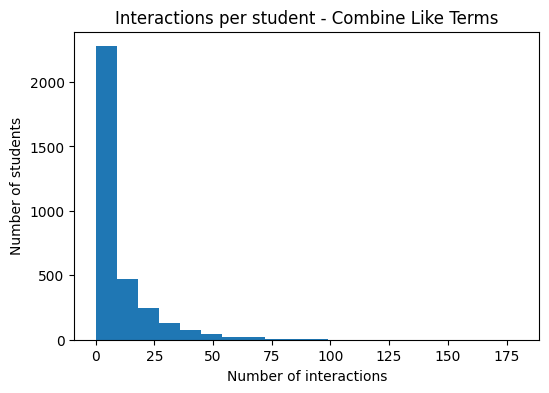

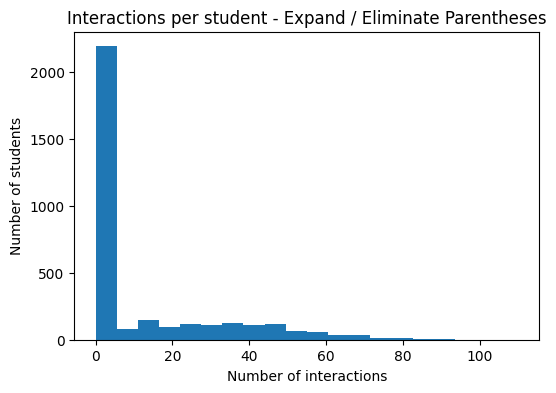

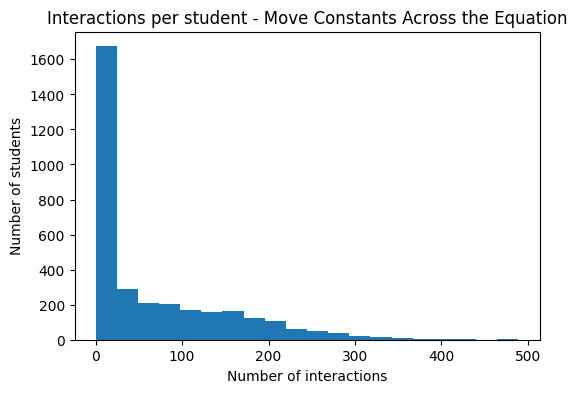

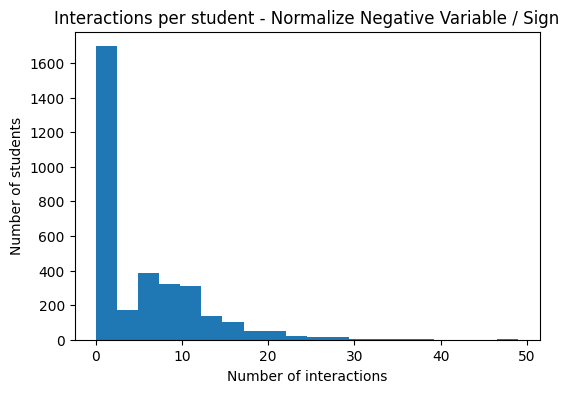

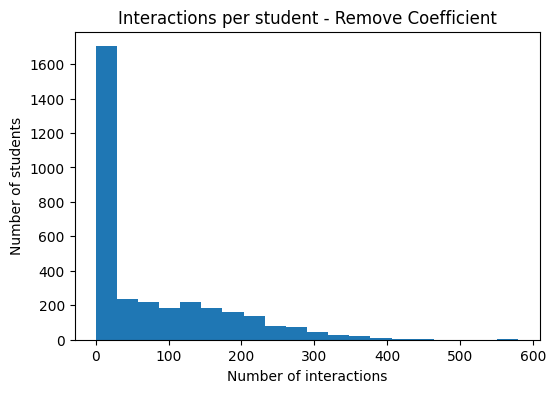

In [14]:
interactions_per_student_skill = (
    df_train.groupby(["skill_name", "Anon Student Id"])
    .size()
    .reset_index(name="n_interactions")
)

print(interactions_per_student_skill.head())
for skill in interactions_per_student_skill["skill_name"].unique():
    sub = interactions_per_student_skill[
        interactions_per_student_skill["skill_name"] == skill
    ]

    plt.figure(figsize=(6,4))
    plt.hist(sub["n_interactions"], bins=20)
    plt.title(f"Interactions per student - {skill}")
    plt.xlabel("Number of interactions")
    plt.ylabel("Number of students")
    plt.show()